# Exercise 9
**Cristina Correa - 1819211867**


Use a maps website to get the actual distance between cities and update
your script. Find the best path to get from Sunderland to Washington.


Here I'll use the amount of miles we have to walk between cities

```
⭕-9.2-⭕       A — 9.2 — F
 | \    |        |\        |
 8 12.3 6.7      8 \       6.7
 |   \  |        |  12.3   |
⭕    `⭕       B      `— S
 |      |        |         |
 10.5   11.4     10.5      11.4
 |      |        |         |
⭕-11.3⭕       C —11.3 — D
```

In [1]:
import heapq
import matplotlib.pyplot as plt
import networkx as nx


# Class representing a node in the graph
class Node:
    def __init__(self, name, heuristic_cost):
        self.name = name
        self.heuristic_cost = heuristic_cost
        self.adjacent = {}
        self.parent = None
        self.g_cost = float("inf")

    def add_neighbor(self, neighbor, cost):
        self.adjacent[neighbor] = cost

    def __lt__(self, other):
        return self.g_cost + self.heuristic_cost < other.g_cost + other.heuristic_cost

In [2]:
# A* search algorithm
def astar_search(start, goal):
    open_list = []
    closed_set = set()
    start.g_cost = 0
    heapq.heappush(open_list, start)

    while open_list:
        current_node = heapq.heappop(open_list)

        if current_node == goal:
            path = []
            while current_node is not None:
                path.append(current_node.name)
                current_node = current_node.parent
            return path[::-1]

        closed_set.add(current_node)

        for neighbor, cost in current_node.adjacent.items():
            tentative_g_cost = current_node.g_cost + cost

            if neighbor in closed_set and tentative_g_cost >= neighbor.g_cost:
                continue

            if tentative_g_cost < neighbor.g_cost or neighbor not in open_list:
                neighbor.g_cost = tentative_g_cost
                neighbor.parent = current_node
                if neighbor not in open_list:
                    heapq.heappush(open_list, neighbor)
    return None

In [3]:
# Creating nodes
A = Node("A", 3)
B = Node("B", 0)  # Washington
C = Node("C", 2)
D = Node("D", 1)
F = Node("F", 4)
S = Node("S", 2)  # Sunderland

# Adding neighbors and their costs
A.add_neighbor(F, 9.2)
A.add_neighbor(B, 8)
A.add_neighbor(S, 12.3)
B.add_neighbor(A, 8) 
B.add_neighbor(C, 10.5)
C.add_neighbor(B, 10.5) 
C.add_neighbor(D, 11.3)
D.add_neighbor(C, 11.3) 
D.add_neighbor(S, 11.4)
S.add_neighbor(A, 12.3) 
S.add_neighbor(F, 6.7)
S.add_neighbor(D, 11.4)
F.add_neighbor(A, 9.2)  
F.add_neighbor(S, 6.7)

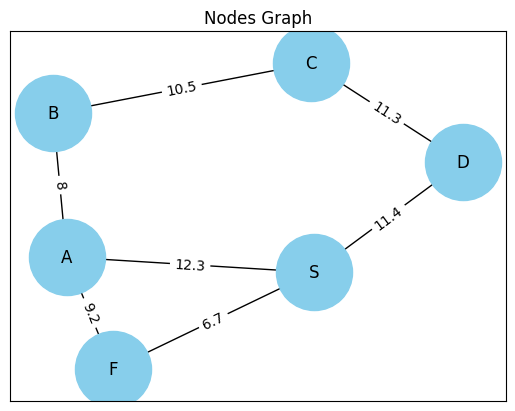

In [4]:
# Visualization without the solution
G = nx.Graph()
edges = [
    (A.name, F.name, {"weight": 9.2}),
    (A.name, B.name, {"weight": 8}),
    (A.name, S.name, {"weight": 12.3}),
    (B.name, C.name, {"weight": 10.5}),
    (C.name, D.name, {"weight": 11.3}),
    (D.name, S.name, {"weight": 11.4}),
    (F.name, S.name, {"weight": 6.7}),
]
G.add_edges_from(edges)

pos = nx.spring_layout(G)
nx.draw_networkx(G, pos, with_labels=True, node_size=3000, node_color="skyblue")
labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.title("Nodes Graph")
plt.show()

In [5]:
path = astar_search(S, B)
print("A* path:", path)

A* path: ['S', 'A', 'B']


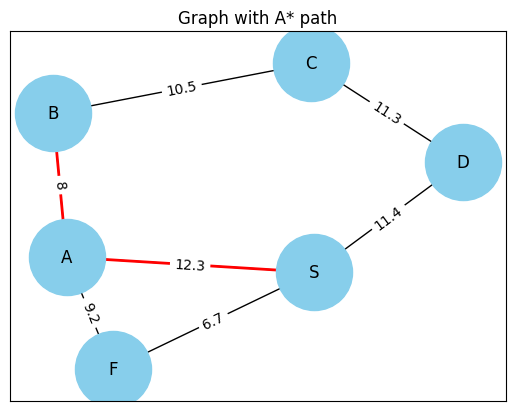

In [6]:
# Visualization with A* path
plt.title("Graph with A* path")
nx.draw_networkx(G, pos, with_labels=True, node_size=3000, node_color="skyblue")
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=[(path[i], path[i + 1]) for i in range(len(path) - 1)],
    edge_color="r",
    width=2,
)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.show()